In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [3]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join('quickdraw_train.npz')
TEST_FILE = os.path.join('quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


In [4]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [6]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


Part A: The Pancake (Width Focus)

In [7]:
class OneLayerPerceptronShallow:
    def __init__(self, input_dim, h1_dim, output_dim, lr=0.01):
        self.lr = lr
        self.initial_lr = lr
        self.momentum = 0.9
        # Hidden layer
        self.W1 = np.random.randn(input_dim, h1_dim) * np.sqrt(2./input_dim)
        self.b1 = np.zeros((1, h1_dim))
        # Output layer
        self.W2 = np.random.randn(h1_dim, output_dim) * np.sqrt(2./h1_dim)
        self.b2 = np.zeros((1, output_dim))

        # ✅ ADD: momentum velocity terms
        self.vW1 = np.zeros_like(self.W1)
        self.vb1 = np.zeros_like(self.b1)
        self.vW2 = np.zeros_like(self.W2)
        self.vb2 = np.zeros_like(self.b2)


    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return Z > 0

    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    # ✅ NEW: Cross-entropy loss for tracking
    def cross_entropy_loss(self, Y_pred, Y_true):
        return -np.mean(np.sum(Y_true * np.log(Y_pred + 1e-8), axis=1))

    # ✅ NEW: LR decay — call this at the end of each epoch
    def decay_lr(self, epoch, decay_rate=0.98):
        self.lr = self.initial_lr * (decay_rate ** epoch)

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def backward(self, X, Y_true, Y_pred):
        m = X.shape[0]

        # Output layer gradient
        dZ2 = Y_pred - Y_true
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # Hidden layer gradient
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # ✅ FIXED: momentum updates instead of plain SGD
        self.vW2 = self.momentum * self.vW2 - self.lr * dW2
        self.vb2 = self.momentum * self.vb2 - self.lr * db2
        self.vW1 = self.momentum * self.vW1 - self.lr * dW1
        self.vb1 = self.momentum * self.vb1 - self.lr * db1

        # Update weights
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1


# ---- DATA EXTRACTION (no change needed here) ----

X_val_list, y_val_list = [], []
for idx in val_dataset.indices:
    sample_data, sample_label = val_dataset.dataset[idx]
    X_val_list.append(sample_data)
    y_val_list.append(sample_label)

X_val_flat = np.array(X_val_list).reshape(len(X_val_list), -1).astype('float32') / 255.0
y_val_flat = np.array(y_val_list)

X_list, y_list = [], []
for idx in train_dataset.indices:
    sample_data, sample_label = train_dataset.dataset[idx]
    X_list.append(sample_data)
    y_list.append(sample_label)

X_train_flat = np.array(X_list).reshape(len(X_list), -1).astype('float32') / 255.0
y_train_flat = np.array(y_list)

Y_train_oh = np.eye(15)[y_train_flat.astype(int)]


# ---- TRAINING LOOP (updated) ----

batch_size = 256  # ✅ NEW: mini-batch size
sig_train_acc, sig_val_acc, sig_loss = [], [], []  # ✅ NEW: added loss tracking
num_epochs = 10

mlp_shallow = OneLayerPerceptronShallow(784, 1024, 15, lr=0.01)

for epoch in range(num_epochs):  # ✅ RENAMED: num_iterations → num_epochs (each loop = 1 full epoch)

    # ✅ NEW: Shuffle training data at the start of every epoch
    indices = np.random.permutation(len(X_train_flat))
    X_shuffled = X_train_flat[indices]
    Y_shuffled = Y_train_oh[indices]

    # ✅ NEW: Mini-batch loop inside each epoch
    for start in range(0, len(X_train_flat), batch_size):
        X_batch = X_shuffled[start:start + batch_size]
        Y_batch = Y_shuffled[start:start + batch_size]

        Y_pred_batch = mlp_shallow.forward(X_batch)
        mlp_shallow.backward(X_batch, Y_batch, Y_pred_batch)

    # ✅ NEW: Decay LR at end of each epoch
    mlp_shallow.decay_lr(epoch)

    # Metrics — compute on full train set after all batches
    Y_pred_train = mlp_shallow.forward(X_train_flat)
    train_loss = mlp_shallow.cross_entropy_loss(Y_pred_train, Y_train_oh)  # ✅ NEW
    train_preds = np.argmax(Y_pred_train, axis=1)
    train_acc = np.mean(train_preds == y_train_flat)
    sig_train_acc.append(train_acc)
    sig_loss.append(train_loss)  # ✅ NEW

    # Validation accuracy
    Y_pred_val = mlp_shallow.forward(X_val_flat)
    val_preds = np.argmax(Y_pred_val, axis=1)
    val_acc = np.mean(val_preds == y_val_flat.flatten())
    sig_val_acc.append(val_acc)

    print(f"Epoch {epoch}: Loss = {train_loss:.4f} | Train Acc = {train_acc:.4f} | Val Acc = {val_acc:.4f}")  # ✅ UPDATED

print(f"\nFinal Training Accuracy: {sig_train_acc[-1]:.4f}")
print(f"Final Validation Accuracy: {sig_val_acc[-1]:.4f}")

Epoch 0: Loss = 2.7062 | Train Acc = 0.1598 | Val Acc = 0.1545
Epoch 1: Loss = 2.7057 | Train Acc = 0.1350 | Val Acc = 0.1265
Epoch 2: Loss = 2.7056 | Train Acc = 0.1095 | Val Acc = 0.1032
Epoch 3: Loss = 2.7054 | Train Acc = 0.1124 | Val Acc = 0.1063
Epoch 4: Loss = 2.7054 | Train Acc = 0.1151 | Val Acc = 0.1094
Epoch 5: Loss = 2.7053 | Train Acc = 0.1217 | Val Acc = 0.1161
Epoch 6: Loss = 2.7053 | Train Acc = 0.1120 | Val Acc = 0.1065
Epoch 7: Loss = 2.7052 | Train Acc = 0.1147 | Val Acc = 0.1081
Epoch 8: Loss = 2.7052 | Train Acc = 0.1198 | Val Acc = 0.1143
Epoch 9: Loss = 2.7051 | Train Acc = 0.1273 | Val Acc = 0.1207

Final Training Accuracy: 0.1273
Final Validation Accuracy: 0.1207


Pancake 2048

In [23]:
class OneLayerPerceptronShallow:
    def __init__(self, input_dim, h1_dim, output_dim, lr=0.01):
        self.lr = lr
        self.initial_lr = lr
        self.momentum = 0.9
        # Hidden layer
        self.W1 = np.random.randn(input_dim, h1_dim) * np.sqrt(2./input_dim)
        self.b1 = np.zeros((1, h1_dim))
        # Output layer
        self.W2 = np.random.randn(h1_dim, output_dim) * np.sqrt(2./h1_dim)
        self.b2 = np.zeros((1, output_dim))

        # ✅ ADD: momentum velocity terms
        self.vW1 = np.zeros_like(self.W1)
        self.vb1 = np.zeros_like(self.b1)
        self.vW2 = np.zeros_like(self.W2)
        self.vb2 = np.zeros_like(self.b2)


    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return Z > 0

    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    # ✅ NEW: Cross-entropy loss for tracking
    def cross_entropy_loss(self, Y_pred, Y_true):
        return -np.mean(np.sum(Y_true * np.log(Y_pred + 1e-8), axis=1))

    # ✅ NEW: LR decay — call this at the end of each epoch
    def decay_lr(self, epoch, decay_rate=0.98):
        self.lr = self.initial_lr * (decay_rate ** epoch)

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def backward(self, X, Y_true, Y_pred):
        m = X.shape[0]

        # Output layer gradient
        dZ2 = Y_pred - Y_true
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # Hidden layer gradient
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # ✅ FIXED: momentum updates instead of plain SGD
        self.vW2 = self.momentum * self.vW2 - self.lr * dW2
        self.vb2 = self.momentum * self.vb2 - self.lr * db2
        self.vW1 = self.momentum * self.vW1 - self.lr * dW1
        self.vb1 = self.momentum * self.vb1 - self.lr * db1

        # Update weights
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1


# ---- DATA EXTRACTION (no change needed here) ----

X_val_list, y_val_list = [], []
for idx in val_dataset.indices:
    sample_data, sample_label = val_dataset.dataset[idx]
    X_val_list.append(sample_data)
    y_val_list.append(sample_label)

X_val_flat = np.array(X_val_list).reshape(len(X_val_list), -1).astype('float32') / 255.0
y_val_flat = np.array(y_val_list)

X_list, y_list = [], []
for idx in train_dataset.indices:
    sample_data, sample_label = train_dataset.dataset[idx]
    X_list.append(sample_data)
    y_list.append(sample_label)

X_train_flat = np.array(X_list).reshape(len(X_list), -1).astype('float32') / 255.0
y_train_flat = np.array(y_list)

Y_train_oh = np.eye(15)[y_train_flat.astype(int)]


# ---- TRAINING LOOP (updated) ----

batch_size = 256  # ✅ NEW: mini-batch size
sig_train_acc, sig_val_acc, sig_loss = [], [], []  # ✅ NEW: added loss tracking
num_epochs = 10

mlp_shallow = OneLayerPerceptronShallow(784, 2048, 15, lr=0.01)

for epoch in range(num_epochs):  # ✅ RENAMED: num_iterations → num_epochs (each loop = 1 full epoch)

    # ✅ NEW: Shuffle training data at the start of every epoch
    indices = np.random.permutation(len(X_train_flat))
    X_shuffled = X_train_flat[indices]
    Y_shuffled = Y_train_oh[indices]

    # ✅ NEW: Mini-batch loop inside each epoch
    for start in range(0, len(X_train_flat), batch_size):
        X_batch = X_shuffled[start:start + batch_size]
        Y_batch = Y_shuffled[start:start + batch_size]

        Y_pred_batch = mlp_shallow.forward(X_batch)
        mlp_shallow.backward(X_batch, Y_batch, Y_pred_batch)

    # ✅ NEW: Decay LR at end of each epoch
    mlp_shallow.decay_lr(epoch)

    # Metrics — compute on full train set after all batches
    Y_pred_train = mlp_shallow.forward(X_train_flat)
    train_loss = mlp_shallow.cross_entropy_loss(Y_pred_train, Y_train_oh)  # ✅ NEW
    train_preds = np.argmax(Y_pred_train, axis=1)
    train_acc = np.mean(train_preds == y_train_flat)
    sig_train_acc.append(train_acc)
    sig_loss.append(train_loss)  # ✅ NEW

    # Validation accuracy
    Y_pred_val = mlp_shallow.forward(X_val_flat)
    val_preds = np.argmax(Y_pred_val, axis=1)
    val_acc = np.mean(val_preds == y_val_flat.flatten())
    sig_val_acc.append(val_acc)

    print(f"Epoch {epoch}: Loss = {train_loss:.4f} | Train Acc = {train_acc:.4f} | Val Acc = {val_acc:.4f}")  # ✅ UPDATED

print(f"\nFinal Training Accuracy: {sig_train_acc[-1]:.4f}")
print(f"Final Validation Accuracy: {sig_val_acc[-1]:.4f}")

Epoch 0: Loss = 2.7059 | Train Acc = 0.1730 | Val Acc = 0.1679
Epoch 1: Loss = 2.7052 | Train Acc = 0.2284 | Val Acc = 0.2242
Epoch 2: Loss = 2.7049 | Train Acc = 0.2287 | Val Acc = 0.2218
Epoch 3: Loss = 2.7047 | Train Acc = 0.2179 | Val Acc = 0.2128
Epoch 4: Loss = 2.7046 | Train Acc = 0.2024 | Val Acc = 0.1963
Epoch 5: Loss = 2.7045 | Train Acc = 0.2086 | Val Acc = 0.2030
Epoch 6: Loss = 2.7044 | Train Acc = 0.2104 | Val Acc = 0.2048
Epoch 7: Loss = 2.7043 | Train Acc = 0.2131 | Val Acc = 0.2063
Epoch 8: Loss = 2.7042 | Train Acc = 0.2039 | Val Acc = 0.1970
Epoch 9: Loss = 2.7042 | Train Acc = 0.2043 | Val Acc = 0.1977

Final Training Accuracy: 0.2043
Final Validation Accuracy: 0.1977


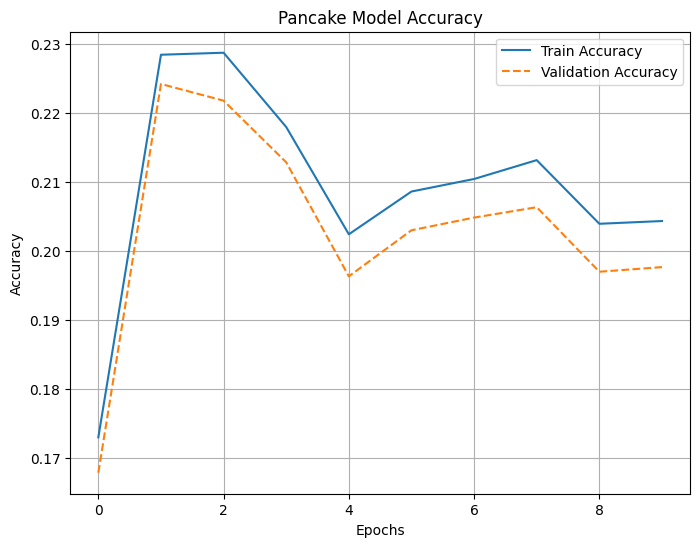

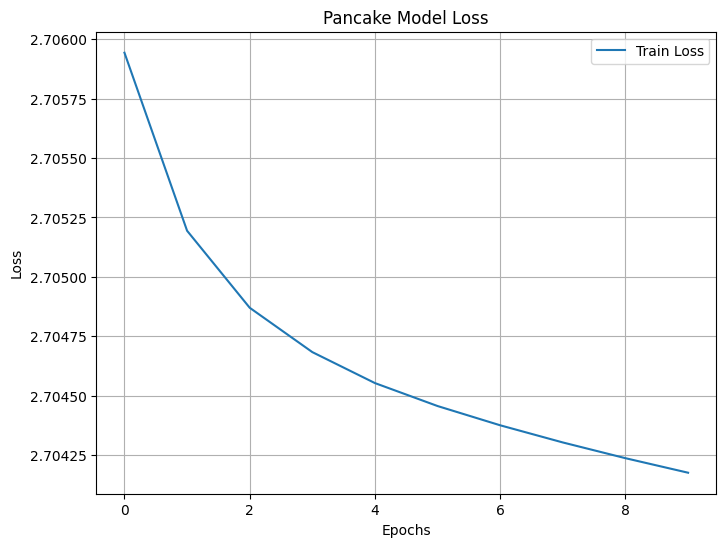

In [24]:
import matplotlib.pyplot as plt

# Example: Pancake model history
# Replace these with your actual lists#
train_acc = sig_train_acc
val_acc   = sig_val_acc
train_loss = sig_loss
#val_loss   = sig_loss_val_pancake  # if available

# ---- Accuracy plot ----
plt.figure(figsize=(8,6))
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy', linestyle='--')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Pancake Model Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ---- Loss plot ----
plt.figure(figsize=(8,6))
plt.plot(train_loss, label='Train Loss')
if 'val_loss' in locals():  # check if validation loss is available
    plt.plot(val_loss, label='Validation Loss', linestyle='--')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Pancake Model Loss")
plt.legend()
plt.grid(True)
plt.show()

Part B: The Tower (Depth Focus)

In [32]:
class TowerMLP:
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=6, lr=0.001):
        self.lr = lr
        self.initial_lr = lr
        self.num_layers = num_layers
        self.momentum = 0.9

        # ✅ Batch Norm parameters (gamma=scale, beta=shift) per layer
        # ✅ Weights: all hidden layers same narrow width
        self.weights = []
        self.biases = []
        self.gammas = []   # BN scale
        self.betas = []    # BN shift
        self.vW = []
        self.vb = []
        self.vgamma = []
        self.vbeta = []

        # Cache for backprop
        self.Z_cache = []
        self.A_cache = []
        self.BN_cache = []  # stores (x_norm, x_centered, std) per layer

        dims = [input_dim] + [hidden_dim] * num_layers + [output_dim]

        for i in range(len(dims) - 1):
            W = np.random.randn(dims[i], dims[i+1]) * np.sqrt(2. / dims[i])
            b = np.zeros((1, dims[i+1]))
            self.weights.append(W)
            self.biases.append(b)
            self.vW.append(np.zeros_like(W))
            self.vb.append(np.zeros_like(b))

            # BN params only for hidden layers (not output)
            if i < num_layers:
                self.gammas.append(np.ones((1, dims[i+1])))
                self.betas.append(np.zeros((1, dims[i+1])))
                self.vgamma.append(np.zeros((1, dims[i+1])))
                self.vbeta.append(np.zeros((1, dims[i+1])))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return Z > 0

    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def cross_entropy_loss(self, Y_pred, Y_true):
        return -np.mean(np.sum(Y_true * np.log(Y_pred + 1e-8), axis=1))

    def decay_lr(self, epoch, decay_rate=0.99):
        self.lr = self.initial_lr * (decay_rate ** epoch)

    # ✅ Batch Normalization forward
    def batch_norm_forward(self, Z, gamma, beta, eps=1e-8):
        mean = np.mean(Z, axis=0, keepdims=True)
        var = np.var(Z, axis=0, keepdims=True)
        x_centered = Z - mean
        std = np.sqrt(var + eps)
        x_norm = x_centered / std
        out = gamma * x_norm + beta
        return out, (x_norm, x_centered, std)

    # ✅ Batch Normalization backward
    def batch_norm_backward(self, dout, cache, gamma):
        x_norm, x_centered, std = cache
        m = dout.shape[0]
        dgamma = np.sum(dout * x_norm, axis=0, keepdims=True)
        dbeta = np.sum(dout, axis=0, keepdims=True)
        dx_norm = dout * gamma
        dvar = np.sum(dx_norm * x_centered * -0.5 * std**-3, axis=0, keepdims=True)
        dmean = np.sum(dx_norm / (-std), axis=0, keepdims=True)
        dZ = dx_norm / std + dvar * 2 * x_centered / m + dmean / m
        return dZ, dgamma, dbeta

    def forward(self, X):
        self.Z_cache = []
        self.A_cache = []
        self.BN_cache = []

        A = X
        self.A_cache.append(A)

        # Hidden layers with BN + ReLU
        for i in range(self.num_layers):
            Z = np.dot(A, self.weights[i]) + self.biases[i]
            self.Z_cache.append(Z)

            # ✅ Apply Batch Norm before ReLU
            Z_bn, bn_cache = self.batch_norm_forward(Z, self.gammas[i], self.betas[i])
            self.BN_cache.append(bn_cache)

            A = self.relu(Z_bn)
            self.A_cache.append(A)

        # Output layer — no BN, no ReLU
        Z_out = np.dot(A, self.weights[-1]) + self.biases[-1]
        self.Z_cache.append(Z_out)
        A_out = self.softmax(Z_out)
        self.A_cache.append(A_out)

        return A_out

    def backward(self, X, Y_true, Y_pred):
        m = X.shape[0]
        dW_list = [None] * len(self.weights)
        db_list = [None] * len(self.biases)
        dgamma_list = [None] * self.num_layers
        dbeta_list = [None] * self.num_layers

        # Output layer gradient
        dZ = Y_pred - Y_true
        dW_list[-1] = np.dot(self.A_cache[-2].T, dZ) / m
        db_list[-1] = np.sum(dZ, axis=0, keepdims=True) / m

        # Backprop through hidden layers
        for i in reversed(range(self.num_layers)):
            dA = np.dot(dZ, self.weights[i+1].T)
            dZ_pre_bn = dA * self.relu_derivative(self.Z_cache[i])

            # ✅ Backprop through Batch Norm
            dZ, dgamma, dbeta = self.batch_norm_backward(dZ_pre_bn, self.BN_cache[i], self.gammas[i])
            dgamma_list[i] = dgamma
            dbeta_list[i] = dbeta

            dW_list[i] = np.dot(self.A_cache[i].T, dZ) / m
            db_list[i] = np.sum(dZ, axis=0, keepdims=True) / m

        # ✅ Momentum updates for weights and biases
        for i in range(len(self.weights)):
            self.vW[i] = self.momentum * self.vW[i] - self.lr * dW_list[i]
            self.vb[i] = self.momentum * self.vb[i] - self.lr * db_list[i]
            self.weights[i] += self.vW[i]
            self.biases[i] += self.vb[i]

        # ✅ Momentum updates for BN params
        for i in range(self.num_layers):
            self.vgamma[i] = self.momentum * self.vgamma[i] - self.lr * dgamma_list[i]
            self.vbeta[i] = self.momentum * self.vbeta[i] - self.lr * dbeta_list[i]
            self.gammas[i] += self.vgamma[i]
            self.betas[i] += self.vbeta[i]


# ---- TRAINING LOOP ----

batch_size = 256
sig_train_acc_tower, sig_val_acc_tower, sig_loss_tower = [], [], []
num_epochs = 40

# ✅ 6 hidden layers of 256 neurons each — narrow and deep
mlp_tower = TowerMLP(input_dim=784, hidden_dim=256, output_dim=15, num_layers=6, lr=0.001)

for epoch in range(num_epochs):

    indices = np.random.permutation(len(X_train_flat))
    X_shuffled = X_train_flat[indices]
    Y_shuffled = Y_train_oh[indices]

    for start in range(0, len(X_train_flat), batch_size):
        X_batch = X_shuffled[start:start + batch_size]
        Y_batch = Y_shuffled[start:start + batch_size]
        Y_pred_batch = mlp_tower.forward(X_batch)
        mlp_tower.backward(X_batch, Y_batch, Y_pred_batch)

    mlp_tower.decay_lr(epoch)

    Y_pred_train = mlp_tower.forward(X_train_flat)
    train_loss = mlp_tower.cross_entropy_loss(Y_pred_train, Y_train_oh)
    train_preds = np.argmax(Y_pred_train, axis=1)
    train_acc = np.mean(train_preds == y_train_flat)
    sig_train_acc_tower.append(train_acc)
    sig_loss_tower.append(train_loss)

    Y_pred_val = mlp_tower.forward(X_val_flat)
    val_preds = np.argmax(Y_pred_val, axis=1)
    val_acc = np.mean(val_preds == y_val_flat.flatten())
    sig_val_acc_tower.append(val_acc)

    print(f"Epoch {epoch}: Loss = {train_loss:.4f} | Train Acc = {train_acc:.4f} | Val Acc = {val_acc:.4f}")

print(f"\nFinal Training Accuracy: {sig_train_acc_tower[-1]:.4f}")
print(f"Final Validation Accuracy: {sig_val_acc_tower[-1]:.4f}")

Epoch 0: Loss = 1.4416 | Train Acc = 0.5184 | Val Acc = 0.5086
Epoch 1: Loss = 1.2261 | Train Acc = 0.5913 | Val Acc = 0.5771
Epoch 2: Loss = 1.1369 | Train Acc = 0.6222 | Val Acc = 0.6059
Epoch 3: Loss = 1.0772 | Train Acc = 0.6439 | Val Acc = 0.6191
Epoch 4: Loss = 1.0326 | Train Acc = 0.6572 | Val Acc = 0.6340
Epoch 5: Loss = 1.0008 | Train Acc = 0.6677 | Val Acc = 0.6401
Epoch 6: Loss = 0.9729 | Train Acc = 0.6772 | Val Acc = 0.6508
Epoch 7: Loss = 0.9460 | Train Acc = 0.6880 | Val Acc = 0.6577
Epoch 8: Loss = 0.9309 | Train Acc = 0.6911 | Val Acc = 0.6613
Epoch 9: Loss = 0.9102 | Train Acc = 0.6981 | Val Acc = 0.6678
Epoch 10: Loss = 0.8946 | Train Acc = 0.7043 | Val Acc = 0.6670
Epoch 11: Loss = 0.8797 | Train Acc = 0.7070 | Val Acc = 0.6729
Epoch 12: Loss = 0.8619 | Train Acc = 0.7137 | Val Acc = 0.6738
Epoch 13: Loss = 0.8498 | Train Acc = 0.7185 | Val Acc = 0.6740
Epoch 14: Loss = 0.8367 | Train Acc = 0.7216 | Val Acc = 0.6727
Epoch 15: Loss = 0.8246 | Train Acc = 0.7271 | Val

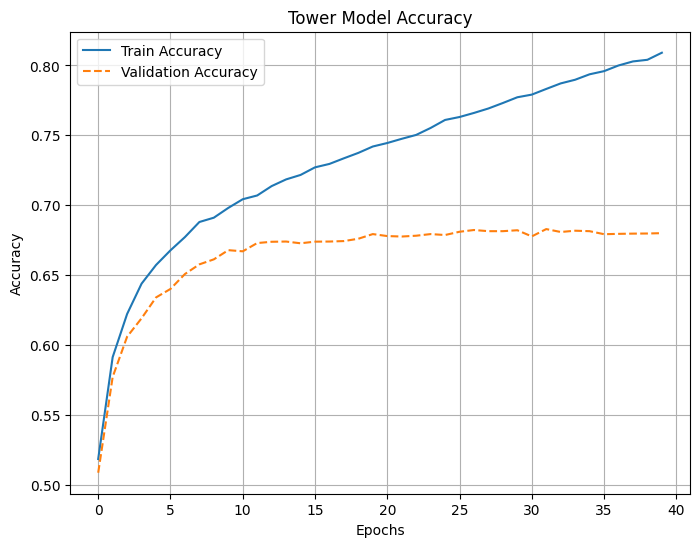

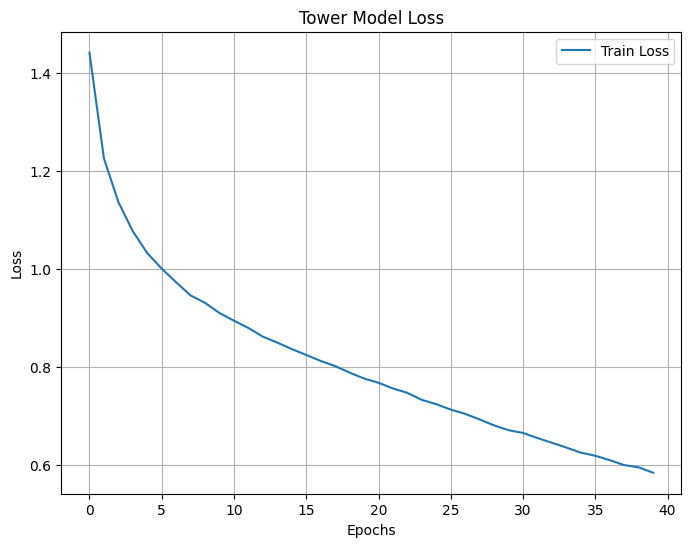

In [33]:
import matplotlib.pyplot as plt

# Example: Pancake model history
# Replace these with your actual lists#
train_acc = sig_train_acc_tower
val_acc   = sig_val_acc_tower
train_loss = sig_loss_tower
#val_loss   = sig_loss_val_pancake  # if available

# ---- Accuracy plot ----
plt.figure(figsize=(8,6))
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy', linestyle='--')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Tower Model Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ---- Loss plot ----
plt.figure(figsize=(8,6))
plt.plot(train_loss, label='Train Loss')
if 'val_loss' in locals():  # check if validation loss is available
    plt.plot(val_loss, label='Validation Loss', linestyle='--')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Tower Model Loss")
plt.legend()
plt.grid(True)
plt.show()

Part C: The Champion (Leaderboard Submission)

In [27]:
def augment_batch(X_batch):
    # small random rotations ±15 degrees
    theta = np.random.uniform(-15, 15, size=(X_batch.shape[0], 1))
    # convert to radians
    theta_rad = theta * np.pi / 180

    # For simplicity, just shift pixels randomly
    shift_x = np.random.randint(-2, 3, size=(X_batch.shape[0],))
    shift_y = np.random.randint(-2, 3, size=(X_batch.shape[0],))

    X_aug = np.empty_like(X_batch)
    for i in range(X_batch.shape[0]):
        img = X_batch[i].reshape(28,28)
        img = np.roll(img, shift_x[i], axis=1)
        img = np.roll(img, shift_y[i], axis=0)
        # optionally apply rotation here
        X_aug[i] = img.flatten()
    return X_aug

In [35]:
# ==========================================
# 4. YOUR IMPLEMENTATION HERE
# ==========================================

class TowerMLP:
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=6, lr=0.001):
        self.lr = lr
        self.initial_lr = lr
        self.num_layers = num_layers
        self.beta1 = 0.9
        self.beta2 = 0.999
        self.eps_adam = 1e-8
        self.t = 0
        self.dropout_rate = 0.0

        self.weights = []
        self.biases = []
        self.gammas = []
        self.betas = []

        self.Z_cache = []
        self.A_cache = []
        self.BN_cache = []

        dims = [input_dim] + [hidden_dim] * num_layers + [output_dim]

        for i in range(len(dims) - 1):
            W = np.random.randn(dims[i], dims[i+1]) * np.sqrt(2. / dims[i])
            b = np.zeros((1, dims[i+1]))
            self.weights.append(W)
            self.biases.append(b)

            if i < num_layers:
                self.gammas.append(np.ones((1, dims[i+1])))
                self.betas.append(np.zeros((1, dims[i+1])))

        # ✅ FIXED: Adam moments initialized AFTER weights/biases/gammas/betas exist
        self.mW = [np.zeros_like(w) for w in self.weights]
        self.vW_adam = [np.zeros_like(w) for w in self.weights]
        self.mb = [np.zeros_like(b) for b in self.biases]
        self.vb_adam = [np.zeros_like(b) for b in self.biases]
        self.mgamma = [np.zeros_like(g) for g in self.gammas]
        self.vgamma_adam = [np.zeros_like(g) for g in self.gammas]
        self.mbeta = [np.zeros_like(b) for b in self.betas]
        self.vbeta_adam = [np.zeros_like(b) for b in self.betas]

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return Z > 0

    def gelu(self, Z):
        return 0.5 * Z * (1 + np.tanh(np.sqrt(2 / np.pi) * (Z + 0.044715 * Z**3)))

    def gelu_derivative(self, Z):
        cdf = 0.5 * (1 + np.tanh(np.sqrt(2 / np.pi) * (Z + 0.044715 * Z**3)))
        pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * Z**2)
        return cdf + Z * pdf


    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def cross_entropy_loss(self, Y_pred, Y_true):
        return -np.mean(np.sum(Y_true * np.log(Y_pred + 1e-8), axis=1))

    def decay_lr(self, epoch, decay_rate=0.95):
        self.lr = self.initial_lr * (decay_rate ** epoch)

    def dropout(self, A):
        mask = (np.random.rand(*A.shape) > self.dropout_rate) / (1 - self.dropout_rate)
        return A * mask

    # ✅ Batch Normalization forward
    def batch_norm_forward(self, Z, gamma, beta, eps=1e-8):
        mean = np.mean(Z, axis=0, keepdims=True)
        var = np.var(Z, axis=0, keepdims=True)
        x_centered = Z - mean
        std = np.sqrt(var + eps)
        x_norm = x_centered / std
        out = gamma * x_norm + beta
        return out, (x_norm, x_centered, std)

    # ✅ Batch Normalization backward
    def batch_norm_backward(self, dout, cache, gamma):
        x_norm, x_centered, std = cache
        m = dout.shape[0]
        dgamma = np.sum(dout * x_norm, axis=0, keepdims=True)
        dbeta = np.sum(dout, axis=0, keepdims=True)
        dx_norm = dout * gamma
        dvar = np.sum(dx_norm * x_centered * -0.5 * std**-3, axis=0, keepdims=True)
        dmean = np.sum(dx_norm / (-std), axis=0, keepdims=True)
        dZ = dx_norm / std + dvar * 2 * x_centered / m + dmean / m
        return dZ, dgamma, dbeta

    def forward(self, X):
        self.Z_cache = []
        self.A_cache = []
        self.BN_cache = []

        A = X
        self.A_cache.append(A)

        # Hidden layers with BN + ReLU
        for i in range(self.num_layers):
            Z = np.dot(A, self.weights[i]) + self.biases[i]
            self.Z_cache.append(Z)

            # ✅ Apply Batch Norm before ReLU
            Z_bn, bn_cache = self.batch_norm_forward(Z, self.gammas[i], self.betas[i])
            self.BN_cache.append(bn_cache)

            A = self.relu(Z_bn)
            #A = self.gelu(Z_bn)
            #self.A_cache.append(A)

            #A = self.gelu(Z_bn)
            A = self.dropout(A)
            self.A_cache.append(A)

        # Output layer — no BN, no ReLU
        Z_out = np.dot(A, self.weights[-1]) + self.biases[-1]
        self.Z_cache.append(Z_out)
        A_out = self.softmax(Z_out)
        self.A_cache.append(A_out)

        return A_out

    def adam_update(self, param, grad, m, v):
        self.t += 1
        m = self.beta1 * m + (1 - self.beta1) * grad
        v = self.beta2 * v + (1 - self.beta2) * grad**2
        m_hat = m / (1 - self.beta1**self.t)
        v_hat = v / (1 - self.beta2**self.t)
        param -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps_adam)
        return param, m, v


    def backward(self, X, Y_true, Y_pred):
        m = X.shape[0]
        dW_list = [None] * len(self.weights)
        db_list = [None] * len(self.biases)
        dgamma_list = [None] * self.num_layers
        dbeta_list = [None] * self.num_layers

        dZ = Y_pred - Y_true
        dW_list[-1] = np.dot(self.A_cache[-2].T, dZ) / m
        db_list[-1] = np.sum(dZ, axis=0, keepdims=True) / m

        for i in reversed(range(self.num_layers)):
            dA = np.dot(dZ, self.weights[i+1].T)
            dZ_pre_bn = dA * self.relu_derivative(self.Z_cache[i])
            #dZ_pre_bn = dA * self.gelu_derivative(self.Z_cache[i])
            dZ, dgamma, dbeta = self.batch_norm_backward(dZ_pre_bn, self.BN_cache[i], self.gammas[i])
            dgamma_list[i] = dgamma
            dbeta_list[i] = dbeta
            dW_list[i] = np.dot(self.A_cache[i].T, dZ) / m
            db_list[i] = np.sum(dZ, axis=0, keepdims=True) / m

        # ✅ Adam updates for weights and biases
        for i in range(len(self.weights)):
            self.weights[i], self.mW[i], self.vW_adam[i] = self.adam_update(
                self.weights[i], dW_list[i], self.mW[i], self.vW_adam[i])
            self.biases[i], self.mb[i], self.vb_adam[i] = self.adam_update(
                self.biases[i], db_list[i], self.mb[i], self.vb_adam[i])

        # ✅ Adam updates for BN params
        for i in range(self.num_layers):
            self.gammas[i], self.mgamma[i], self.vgamma_adam[i] = self.adam_update(
                self.gammas[i], dgamma_list[i], self.mgamma[i], self.vgamma_adam[i])
            self.betas[i], self.mbeta[i], self.vbeta_adam[i] = self.adam_update(
                self.betas[i], dbeta_list[i], self.mbeta[i], self.vbeta_adam[i])

    def eval(self):
        return self

    def to(self, device):
        return self

    def __call__(self, X):

        if isinstance(X, torch.Tensor):
          X_np = X.detach().cpu().numpy()
        else:
          X_np = X

          # Flatten if needed
        if len(X_np.shape) > 2:
            X_np = X_np.reshape(X_np.shape[0], -1)

          # Normalize if needed
        if X_np.max() > 1:
            X_np = X_np.astype("float32") / 255.0

        outputs_np = self.forward(X_np)

        return torch.tensor(outputs_np, dtype=torch.float32)


# ---- DATA EXTRACTION (no change needed here) ----

X_val_list, y_val_list = [], []
for idx in val_dataset.indices:
    sample_data, sample_label = val_dataset.dataset[idx]
    X_val_list.append(sample_data)
    y_val_list.append(sample_label)

#X_val_flat = np.array(X_val_list).reshape(len(X_val_list), -1).astype('float32') / 255.0
y_val_flat = np.array(y_val_list)

X_train_flat = (X_train_flat - np.mean(X_train_flat, axis=0)) / (np.std(X_train_flat, axis=0)+1e-8)
X_val_flat   = (X_val_flat - np.mean(X_val_flat, axis=0)) / (np.std(X_val_flat, axis=0)+1e-8)


X_list, y_list = [], []
for idx in train_dataset.indices:
    sample_data, sample_label = train_dataset.dataset[idx]
    X_list.append(sample_data)
    y_list.append(sample_label)

#X_train_flat = np.array(X_list).reshape(len(X_list), -1).astype('float32') / 255.0
y_train_flat = np.array(y_list)

Y_train_oh = np.eye(15)[y_train_flat.astype(int)]
# ---- TRAINING LOOP ----

batch_size = 256
sig_train_acc_tower, sig_val_acc_tower, sig_loss_tower = [], [], []
num_epochs = 30

# ✅ 6 hidden layers of 256 neurons each — narrow and deep
mlp_champion = TowerMLP(input_dim=784, hidden_dim=256, output_dim=15, num_layers=3, lr=0.0015)

for epoch in range(num_epochs):

    indices = np.random.permutation(len(X_train_flat))
    X_shuffled = X_train_flat[indices]
    Y_shuffled = Y_train_oh[indices]

    for start in range(0, len(X_train_flat), batch_size):
        X_batch = X_shuffled[start:start + batch_size]
        Y_batch = Y_shuffled[start:start + batch_size]

        # Apply augmentation here
        X_batch = augment_batch(X_batch)

        Y_pred_batch = mlp_tower.forward(X_batch)
        mlp_tower.backward(X_batch, Y_batch, Y_pred_batch)

    mlp_tower.decay_lr(epoch)

    Y_pred_train = mlp_tower.forward(X_train_flat)
    train_loss = mlp_tower.cross_entropy_loss(Y_pred_train, Y_train_oh)
    train_preds = np.argmax(Y_pred_train, axis=1)
    train_acc = np.mean(train_preds == y_train_flat)
    sig_train_acc_tower.append(train_acc)
    sig_loss_tower.append(train_loss)

    Y_pred_val = mlp_tower.forward(X_val_flat)
    val_preds = np.argmax(Y_pred_val, axis=1)
    val_acc = np.mean(val_preds == y_val_flat.flatten())
    sig_val_acc_tower.append(val_acc)

    print(f"Epoch {epoch}: Loss = {train_loss:.4f} | Train Acc = {train_acc:.4f} | Val Acc = {val_acc:.4f}")

print(f"\nFinal Training Accuracy: {sig_train_acc_tower[-1]:.4f}")
print(f"Final Validation Accuracy: {sig_val_acc_tower[-1]:.4f}")




Epoch 0: Loss = 0.7157 | Train Acc = 0.7673 | Val Acc = 0.6826
Epoch 1: Loss = 0.7583 | Train Acc = 0.7547 | Val Acc = 0.6879
Epoch 2: Loss = 0.7668 | Train Acc = 0.7528 | Val Acc = 0.6990
Epoch 3: Loss = 0.7639 | Train Acc = 0.7534 | Val Acc = 0.6997
Epoch 4: Loss = 0.7639 | Train Acc = 0.7535 | Val Acc = 0.7003
Epoch 5: Loss = 0.7657 | Train Acc = 0.7528 | Val Acc = 0.7046
Epoch 6: Loss = 0.7653 | Train Acc = 0.7527 | Val Acc = 0.7063
Epoch 7: Loss = 0.7627 | Train Acc = 0.7516 | Val Acc = 0.7048
Epoch 8: Loss = 0.7630 | Train Acc = 0.7519 | Val Acc = 0.7093
Epoch 9: Loss = 0.7599 | Train Acc = 0.7517 | Val Acc = 0.7076
Epoch 10: Loss = 0.7569 | Train Acc = 0.7533 | Val Acc = 0.7097
Epoch 11: Loss = 0.7592 | Train Acc = 0.7492 | Val Acc = 0.7096
Epoch 12: Loss = 0.7561 | Train Acc = 0.7517 | Val Acc = 0.7130
Epoch 13: Loss = 0.7540 | Train Acc = 0.7521 | Val Acc = 0.7134
Epoch 14: Loss = 0.7534 | Train Acc = 0.7519 | Val Acc = 0.7160
Epoch 15: Loss = 0.7512 | Train Acc = 0.7532 | Val

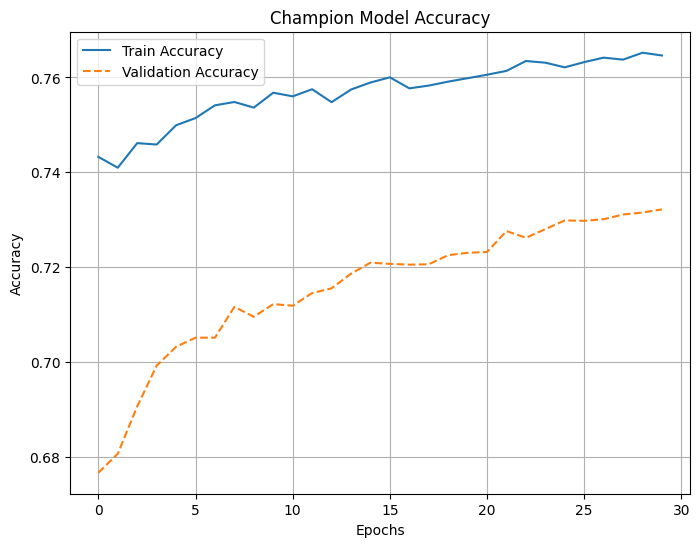

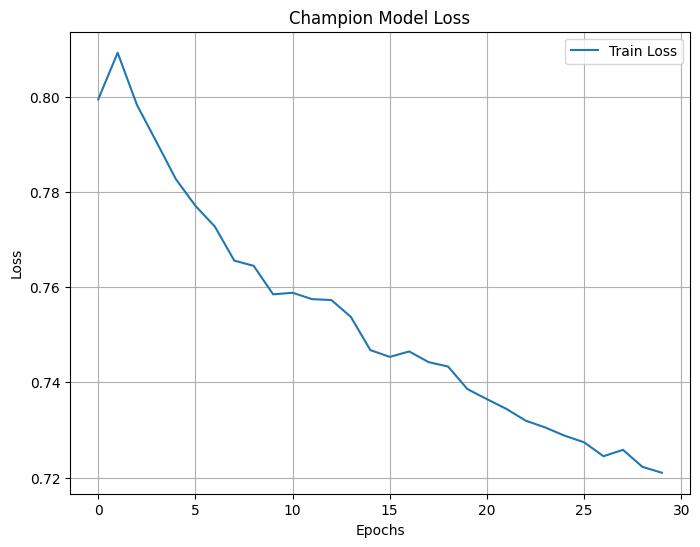

In [31]:
import matplotlib.pyplot as plt

# Example: Pancake model history
# Replace these with your actual lists#
train_acc = sig_train_acc_tower
val_acc   = sig_val_acc_tower
train_loss = sig_loss_tower
#val_loss   = sig_loss_val_pancake  # if available

# ---- Accuracy plot ----
plt.figure(figsize=(8,6))
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy', linestyle='--')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Champion Model Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ---- Loss plot ----
plt.figure(figsize=(8,6))
plt.plot(train_loss, label='Train Loss')
if 'val_loss' in locals():  # check if validation loss is available
    plt.plot(val_loss, label='Validation Loss', linestyle='--')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Champion Model Loss")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(mlp_champion, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [16]:
# ==========================================
# PARAMETER COUNT FOR NUMPY MODEL
# ==========================================

def print_model_size(model):
    total_params = 0

    # Count weights
    for W in model.weights:
        total_params += W.size

    # Count biases
    for b in model.biases:
        total_params += b.size

    # Count BatchNorm gammas
    for g in model.gammas:
        total_params += g.size

    # Count BatchNorm betas
    for b in model.betas:
        total_params += b.size

    print("\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")

    if total_params > 3_000_000:
        print("  ❌ WARNING: Model exceeds 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

    return total_params

In [18]:
print_model_size(mlp_champion)


Model Statistics:
  Total Parameters: 337,935
  ✅ Parameter count is within limits.


337935

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_images(dataset, num_images=16, title_prefix=""):
    plt.figure(figsize=(8, 8))
    for i in range(num_images):
        img, label = dataset[i]

        # --- Reshape flattened images ---
        if img.ndim == 1:  # flattened vector
            side_len = int(np.sqrt(img.shape[0]))
            img_np = img.reshape(side_len, side_len)
        else:
            img_np = np.array(img)

        plt.subplot(4, 4, i + 1)
        plt.imshow(img_np, cmap='gray')
        plt.title(str(label))
        plt.axis('off')

    plt.suptitle(title_prefix)
    plt.show()

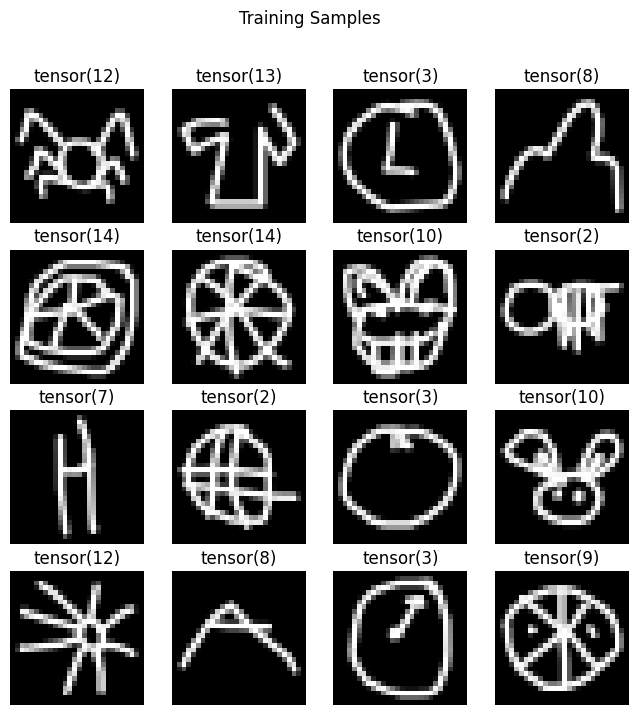

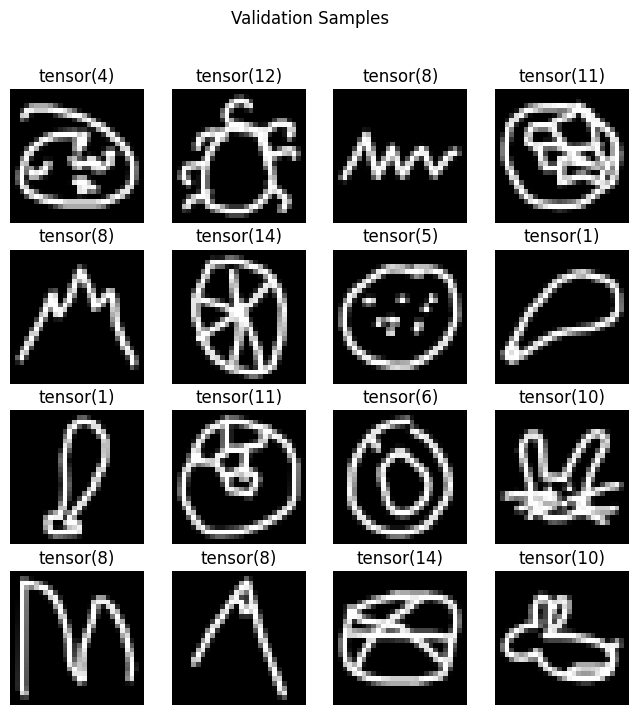

In [73]:
show_images(train_dataset, num_images=16, title_prefix="Training Samples")
show_images(val_dataset, num_images=16, title_prefix="Validation Samples")

Confusion Matrix

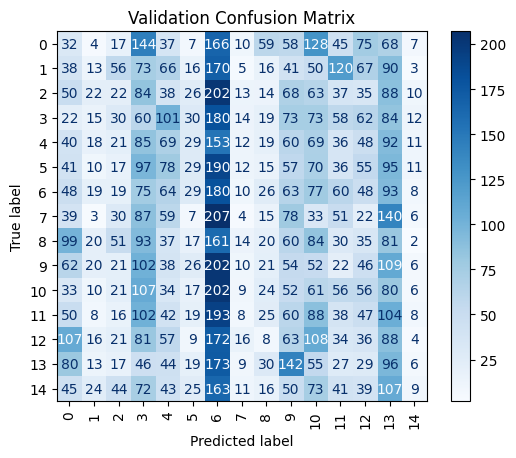

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ---- 1. Get predictions from your champion model ----
# Assume your model is called mlp_tower
# X_val_flat and y_val_flat are your validation data

# Forward pass
Y_val_pred = mlp_champion.forward(X_val_flat)

# Convert probabilities to predicted class indices
y_val_pred = np.argmax(Y_val_pred, axis=1)

# ---- 2. Compute confusion matrix ----
cm = confusion_matrix(y_val_flat.flatten(), y_val_pred)

# ---- 3. Display confusion matrix ----
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Validation Confusion Matrix")
plt.show()

Accuracy and Loss curves